In [1]:
%reload_ext autoreload
%autoreload 2

import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HDF5_USE_FILE_LOCKING"]= "FALSE"
    
from scipy.constants import mu_0
import MaNTA

from Objective2 import make_objective


import jax
import jax.numpy as jnp
import equinox as eqx 
import yancc

from yancc_wrapper2 import yancc_data

import desc
from desc import set_device
set_device("gpu")
import desc.io
from desc.equilibrium import Equilibrium
from desc.geometry import FourierRZToroidalSurface
from desc.grid import Grid, LinearGrid
from desc.objectives import (
    AspectRatio,
    FixBoundaryR,
    FixBoundaryZ,
    FixCurrent,
    FixPsi,
    ForceBalance,
    LinearObjectiveFromUser,
    ObjectiveFunction,
    ObjectiveFromUser,
    RotationalTransform,
    Volume,
)
from desc.profiles import SplineProfile
import matplotlib.pyplot as plt


Registering cpu implementation for operation get_solution
Registering gpu implementation for operation get_solution
Registering cpu implementation for operation get_adjoint_gradients
Registering gpu implementation for operation get_adjoint_gradients
Registering cpu implementation for operation run
Registering cpu implementation for operation run_ss
Using cache directory: /global/cfs/cdirs/mp217/eatocco/__pycache__
[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


/global/cfs/cdirs/mp217/eatocco/DESC/desc/__init__.py:151: UserWarning: CUDA_VISIBLE_DEVICES= did not match any physical GPU (id=['0', '1', '2', '3']), falling back to CPU
  warnings.warn(


In [2]:
from Stellarator2 import StellaratorTransport

fname = "stellarator_opt"

eq_name = "eq"

# st_config = {
#     "SourceCenter": 0.1,
#     "SourceHeight": 40.0,
#     "SourceWidth": 0.8,
#     "EdgeTemperature":0.25,
#     "EdgeDensity": 0.0,
#     "n0": 1.0,
# }

# st_config = {
#     "SourceCenter": 0.2,
#     "SourceHeight": 9.0,
#     "SourceWidth": 0.4,
#     "EdgeTemperature":0.1,
#     "EdgeDensity": 0.0,
#     "n0": 1.0,
# }

st_config = {
    "SourceCenter": 0.2,
    "SourceHeight": 150.0,
    "SourceWidth": 0.8,
    "EdgeTemperature":0.1,
    "EdgeDensity": 0.0,
    "n0": 0.5,
}

rho_upper = 1.0
rtol = 1e-2
atol = 1e-3

# # %%
solver_config = {
    "OutputFilename": "stellarator_opt0",
    "Polynomial_degree": 4,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-2,
    "initialTimestep": 1e-7,
    "MinStepSize": 1e-9, 
    "SteadyStateTolerance": 1e-4,
    "restart": False,
    "solveAdjoint": True, 
    "zeroFlux": True,
}


config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

points =  MaNTA.getNodes(solver_config["Lower_boundary"], solver_config["Upper_boundary"], solver_config["Grid_size"], solver_config["Polynomial_degree"])


yancc_rho = jnp.array(points)
yancc_ntheta = 17
yancc_nzeta = 23

yancc_res = {"na":43,"nx":5}

# to allow maximum flexibility to match manta, we use a spline with the same control points as manta \
# + axis and lcfs
# initial pressure is all zeros, can change this if desired

pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)

surf = FourierRZToroidalSurface(
    R_lmn=[1, 0.125, 0.1],
    Z_lmn=[-0.125, -0.1],
    modes_R=[[0, 0], [1, 0], [0, 1]],
    modes_Z=[[-1, 0], [0, -1]],
    NFP=4,
)
# create initial equilibrium. Psi chosen to give B ~ 1 T. Could also give profiles here,
# default is zero pressure and zero current
eq = Equilibrium(M=4, N=4, Psi=0.1, surface=surf, pressure=desc_pressure)
# this is usually all you need to solve a fixed boundary equilibrium
eq = eq.solve(x_scale="ess")[0]
# print(pressure_rho)

# eq = desc.examples.get("W7-X")

# # Reduce the number of modes (not sure if this is a good thing to do)
# eq.change_resolution(M=4, N=4,L_grid=len(points), M_grid = 8, N_grid=8)# 
# eq = eq.solve(x_scale="ess")[0]
# eq = desc.examples.get("ESTELL")
# surf = eq.get_surface_at(rho=1)
# # eq.change_resolution(M=4, N=4,L_grid=len(points), M_grid=4, N_grid=4)# 
# eq = Equilibrium(M=4, N=4, Psi=0.5, surface=surf, pressure=desc_pressure)
# eq = eq.solve(x_scale="ess")[0]

# eq = desc.io.load("eq_self_consistent_pressure.h5")
# desc_pressure = eq.get_profile('p')
eq_init = eq.copy()

V0 = eq.compute("V")["V"]
# yancc_wrapper = yancc_data.from_eq(points, grid = yancc_grid,rho = yancc_rho, Density=Density, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_wrapper = yancc_data.from_eq(points, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta, **yancc_res)

Building objective: force
Precomputing transforms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Number of parameters: 120
Number of objectives: 850

Starting optimization
Using method: lsq-exact
Optimization terminated successfully.
`ftol` condition satisfied. (ftol=1.00e-02)
         Current function value: 7.266e-08
         Total delta_x: 1.735e-01
         Iterations: 7
         Function evaluations: 10
         Jacobian evaluations: 8
Initializing yancc wrapper
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=43, nx=5.


configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 65
Configuration done.


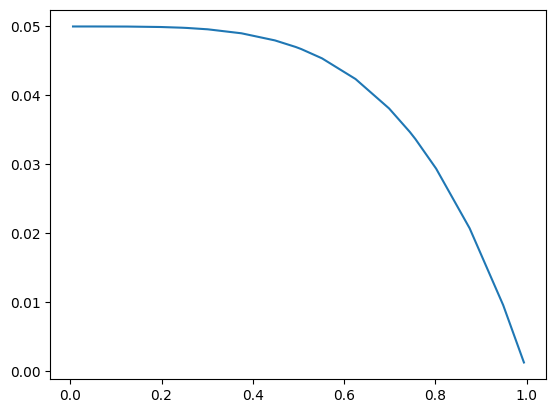

In [3]:


st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
plt.plot(points, 2./3. * st.InitialValue(0, points) / yancc_wrapper.Vp)

In [4]:
st.run()

Setting initial conditions
Residual norm at t = 0: inf
Residual norm at t = 0: 0
Residual norm at t = 0: 2.81098e-83
Residual norm at t = 0: 2.01733


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 11.7953
Residual norm at t = 1e-07: inf
Residual norm at t = 1e-07: 0.0613526
Residual norm at t = 2e-07: 5.61804e-06
Residual norm at t = 4e-07: 0.000820657
Residual norm at t = 8e-07: 0.000560533
Residual norm at t = 1.6e-06: 0.00625141
Residual norm at t = 3.2e-06: 0.00533224
Residual norm at t = 6.4e-06: 0.0116514
Residual norm at t = 6.4e-06: 0.126083
Residual norm at t = 9.6e-06: 7.37138e-05
Residual norm at t = 1.6e-05: 0.117442
Residual norm at t = 1.6e-05: 0.685026
Residual norm at t = 2.24e-05: 0.000414766
Residual norm at t = 2.88e-05: 0.250448
Residual norm at t = 3.52e-05: 0.291322
Residual norm at t = 4.8e-05: 0.0997133
Residual norm at t = 4.8e-05: 0.34648
Residual norm at t = 6.08e-05: 0.000927811
Residual norm at t = 7.36e-05: 0.243477
Residual norm at t = 9.92e-05: 0.218988
Residual norm at t = 9.92e-05: 0.193978
Residual norm at t = 0.0001248: 0.098304
Residual norm at t = 0.0001504: 0.156786
Residual norm at t = 0.0001504: 0.473967
Residual n

Writing output at 0.01 ( 66 timesteps )


Residual norm at t = 0.01: 7.89732


 dy/dt norm inferred from lambdas is 0.0163398
Steady State achieved at time t = 0.01
Total Number of Timesteps             :66
Total Number of Residual Evaluations  :136
Total Number of Jacobian Computations :20
Computing adjoints


INFO: Computing adjoints for 4004 parameters
Successfully computed dgdp
4004
20


Done.


In [ ]:
from desc.plotting import plot_1d
from desc.equilibrium import EquilibriaFamily

solver_config = {
    "OutputFilename": fname,
    "RestartFile": "stellarator_opt0.restart.nc",
    "Polynomial_degree": 4,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-2,
    "initialTimestep": 1e-5,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-4,
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

fig, ax = plt.subplots()

eq2 = eq.copy()
fam2 = EquilibriaFamily(eq2)
niters = 3
for k in range(niters):
    eq2 = eq2.copy()

    fig, ax = plot_1d(eq2, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq2, nt = yancc_ntheta, nz = yancc_nzeta, **yancc_res)
    pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()
    
    print(pi)
    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq2.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq2, _ = eq2.solve(objective="force", optimizer="lsq-exact", verbose=3)
    fam2.append(eq2)

eq_self_consistent = eq2.copy()

ax.legend()

Initializing yancc wrapper
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=43, nx=5.
configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 65
Configuration done.
Setting initial conditions
Residual norm at t = 0: -nan
Residual norm at t = 0: 0
Residual norm at t = 0: 1.57138e+101
Residual norm at t = 0: 0.0153342


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 0.0237129
Residual norm at t = 1e-05: 0
Residual norm at t = 2e-05: 0.000721467
Residual norm at t = 4e-05: 0.000515213
Residual norm at t = 8e-05: 0.00160421
Residual norm at t = 0.00016: 0.000608318
Residual norm at t = 0.00032: 0.000334741
Residual norm at t = 0.00064: 0.000100801
Residual norm at t = 0.00128: 0.000266526
Residual norm at t = 0.00256: 0.000659565
Residual norm at t = 0.00512: 0.00191144
Residual norm at t = 0.01024: 0.00617668
Residual norm at t = 0.01024: 0.0174043


Writing output at 0.01 ( 11 timesteps )


...

INFO: Computing adjoints for 4004 parameters
Successfully computed dgdp
4004
20


Done.
[3961.34372712 3970.07852597 3906.14228107 3819.59354353 3750.76867925
 3728.25590447 3652.97681707 3492.2915432  3298.41333806 3150.90671815
 3108.93737758 2940.10766158 2613.79918904 2223.7108253  1945.57035546
 1870.701481   1552.81894968 1001.54363369  394.94708391   41.47012915]
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 100 ms
Timer: Objective build = 114 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 146 ms
Timer: LinearConstraintProjection build = 43.3 ms
Number of parameters: 120
Number of objectives: 850
Timer: Initializing the optimization = 308 ms

Starting optim

Total HDG degrees of freedom 65
Configuration done.
Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: -nan
Residual norm at t = 0: 0
Residual norm at t = 0: 0.134385


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 0.410074
Residual norm at t = 1e-05: 0
Residual norm at t = 1e-05: 0.247951
Residual norm at t = 2e-05: 0.00315282
Residual norm at t = 4e-05: 0.0957721
Residual norm at t = 4e-05: 0.223544


In [ ]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq2], labels=["Initial", "self-consistent"]
)

In [ ]:
eq = eq2.copy()


In [ ]:
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 4,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 0.001,
    "initialTimestep": 1e-5,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-4,
}
config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

manta_objective = make_objective(config, yancc_res=yancc_res)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime) 

#     return stored_energy, pressure

def objective_from_user_fun(grid, data):
  # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data['V(r)'])
    V_r = grid.compress(data['V_r(r)'])
    V_rr = grid.compress(data['V_rr(r)'])
    Vp = V_r/V[-1]
    Vpp = V_rr/V[-1]
    
    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")
    
    stored_energy, manta_pressure = manta_objective((fields, Vp, Vpp), grid)
    print("------------ STORED ENERGY ----------------")
    print(stored_energy)
    print("-------------------------------------------")
    
    pressure_error = manta_pressure - desc_pressure # not sure if the sign makes the difference here

    print("------------TOTAL PRESSURE ERROR-----------")
    print(pressure_error)
    print("-------------------------------------------")

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return 1 / stored_energy #jnp.append(pressure_error, 1 / stored_energy)

yancc_desc_grid = yancc_wrapper.grid

# domain_boundary_rho = rho_from_normalized_volume(0.9)
domain_boundary_rho = 1.0
def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l)
    return jnp.array([dp0, p1]).squeeze()


pressure_constraint_target = jnp.array([0.0, 0.0])
# pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])

In [ ]:

# other objectives are non-dimensionalized, so weights should account for that
# and handle relative weighting, this will likely need trial and error
# pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1e-5)

pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1e-6)
stored_energy_weight = 1.0
objective_from_user_weight = stored_energy_weight#jnp.append(stored_energy_weight)

objectives = [
    # AspectRatio(eq=eq, target=6, weight=10),
    Volume(eq=eq, target=V0, weight=0.5),
    # RotationalTransform(eq=eq, target=0.42, weight=10),
    ObjectiveFromUser(
        objective_from_user_fun,
        eq,
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd", 
        # need this assuming manta only has vjp, if using jvp switch to fwd
    ),
]
k = 2
R_modes = jnp.vstack(
    (
        [0, 0, 0],
        eq.surface.R_basis.modes[
            jnp.max(jnp.abs(eq.surface.R_basis.modes), 1) > k, :
        ],
    )
)
Z_modes = eq.surface.Z_basis.modes[
    jnp.max(jnp.abs(eq.surface.Z_basis.modes), 1) > k, :
]
constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    FixCurrent(eq=eq),  # fix zero current, eventually should use real bootstrap
    # Volume(eq=eq, target=V0), # fix volume of outer flux surface
    # FixBoundaryR(eq=eq, modes=R_modes),
    # FixBoundaryZ(eq=eq, modes=Z_modes),
    FixPsi(eq=eq),  # fix total magnetic flux
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]

objective = ObjectiveFunction(objectives)
objective.build(use_jit=False)
# print(objective.jac_scaled(objective.x(eq)))
eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-lsq-exact",
    x_scale="ess",
    maxiter=10,
    ftol=1e-3,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    # options={
    #     "initial_trust_radius": 5e-4,   
    #     "perturb_options": {"order": 2, "verbose": 3},  # use 2nd-order perturbations
    # #     # "solve_options": {
    # #     #     "ftol": 5e-3,
    # #     #     "xtol": 1e-6,
    # #     #     "gtol": 1e-6,
    # #     #     "verbose": 3,
    #     # },  # for equilibrium subproblem
    # },
    verbose=3,
    copy=True,
)

eq_optimized = eq.copy()

In [ ]:
# final self consistency 
fig, ax = plt.subplots()
niters = 2
for k in range(niters):
    eq = eq.copy()

    fig, ax = plot_1d(eq, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq, nt = yancc_ntheta, nz = yancc_nzeta)
 
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()

    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq, _ = eq.solve(objective="force", x_scale ="ess", optimizer="lsq-exact", verbose=3)


ax.legend()
eq_optimized_self_consistent = eq.copy()

In [ ]:
eq_optimized_self_consistent.save(eq_name + "optimized_equilibrium.h5")

In [ ]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq], labels=["Initial", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boundaries

plot_comparison(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
plot_boundaries(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boozer_surface, plot_boundaries, plot_qs_error
# eq = desc.io.load("../python/eq2optimized_equilibrium.h5")#desc.examples.get("ESTELL")
# plot_boozer_surface(eq_init, fieldlines=8)
plot_boozer_surface(eq, fieldlines=8)
# plot_qs_error(eq_init)
plot_qs_error(eq)